# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

Before you start, install the some of the required packages. 

In [1]:
!python -m pip install kaggle==1.6.12

In [2]:
!pip install ucimlrepo

**Note:** Restart the kernel to use updated package(s).

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
In 2-4 sentences, explain the kind of problem you want to look at and the datasets you will be wrangling for this project.

---
Data pollution is a health issue and we know flying is one major source of pollution. Several factors contribute to pollution and we want to know is aviation is one of the main ones. Can we see the impact of the flights on the air quality?  

To do so, we gathered 2 datasets: one depicting the airline flight routes in the US from 1993 to 2024 and the other one showing the most polluted cities and countries (IQAir Index). Both come from kaggle.com

---

Finding the right datasets can be time-consuming. Here we provide you with a list of websites to start with. But we encourage you to explore more websites and find the data that interests you.

* Google Dataset Search https://datasetsearch.research.google.com/
* The U.S. Government’s open data https://data.gov/
* UCI Machine Learning Repository https://archive.ics.uci.edu/ml/index.php


### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### **Dataset 1**

I selected this dataset because it provides a comprehensive overview of domestic airline routes within the United States.

Type: CSV File

Method: The data was gathered using the kaggle API from https://www.kaggle.com/datasets/oleksiimartusiuk/all-airline-fight-routes-in-the-us

Main dataset variables:

- Year
- Quarter
- City Market IDs
- Departure City
- Arrival City
- Miles: The distance between the origin and arrival cities in miles.
- Average Daily Passengers: The average number of passengers flying this route per day.
- Average Fare: The average fare paid by passengers for this route (consider including currency information).

In [3]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Authenticate with Kaggle
api = KaggleApi()
api.authenticate()

# Download and unzip dataset into a target folder
api.dataset_download_files("oleksiimartusiuk/all-airline-fight-routes-in-the-us", path="./data", unzip=True)

# rename te file with a smaller name
os.rename("./data/Consumer_Airfare_Report__Table_1a_-_All_U.S._Airport_Pair_Markets_20240712.csv", "./data/raw_us_flights.csv")

Dataset URL: https://www.kaggle.com/datasets/oleksiimartusiuk/all-airline-fight-routes-in-the-us


In [5]:
# load the file into a dataframe
us_flights_df = pd.read_csv("./data/raw_us_flights.csv", low_memory=False)
us_flights_df.head()

,tbl,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,...,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,Geocoded_City1,Geocoded_City2,tbl1apk
0,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,ABE,...,81.43,G4,1.0000,81.43,G4,1.0000,81.43,NaN,NaN,202131013514112ABEPIE
1,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,ABE,...,208.93,DL,0.4659,219.98,UA,0.1193,154.11,NaN,NaN,202131013515304ABETPA
2,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,ABQ,...,184.56,WN,0.9968,184.44,WN,0.9968,184.44,NaN,NaN,202131014011259ABQDAL
3,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,ABQ,...,182.64,AA,0.9774,183.09,AA,0.9774,183.09,NaN,NaN,202131014011298ABQDFW
4,Table1a,2021,3,30140,30466,"Albuquerque, NM","Phoenix, AZ",10140,14107,ABQ,...,177.11,WN,0.6061,184.49,AA,0.3939,165.77,NaN,NaN,202131014014107ABQPHX


In [6]:
# print the features
us_flights_df.columns

Index(['tbl', 'Year', 'quarter', 'citymarketid_1', 'citymarketid_2', 'city1',
       'city2', 'airportid_1', 'airportid_2', 'airport_1', 'airport_2',
       'nsmiles', 'passengers', 'fare', 'carrier_lg', 'large_ms', 'fare_lg',
       'carrier_low', 'lf_ms', 'fare_low', 'Geocoded_City1', 'Geocoded_City2',
       'tbl1apk'],
      dtype='str')

In [7]:
# select the features that will be of use for our analysis
clean_us_flights_df = us_flights_df[['Year','quarter', 'city1','city2','airportid_1', 'airportid_2','passengers']].copy()

#### Dataset 2

I selected this dataset because it shows the most polluted cities around the world. Mapping them to the previous dataset will enable us to answer our research question.

Type: CSV File

Method: The data was gathered using the "Download file" method from Kaggle website
        The data was gathered using the Download file method from https://www.kaggle.com/datasets/ramjasmaurya/most-polluted-cities-and-countries-iqair-index

Dataset variables:

- Flight_ID: Unique identifiers for each flight.
- Date: Timestamps indicating the date of each flight.
- Time: Timestamps indicating the time of each flight.
- Departure_Airport: Details about the departure airport.
- Arrival_Airport: Details about the arrival airport.
- Temperature_Celsius: Temperature readings at the time of each flight.
- Wind_Speed_knots: Information on wind speed during flight times.
- Turbulence_Level: Categorized into High, Medium, or Low, indicating the level of turbulence experienced during flights.
- Visibility_km: Visibility conditions during flight operations.


IQAir:


In [8]:
#FILL IN 2nd data gathering and loading method
iqair_df = pd.read_csv("./data/raw_air_quality_index.csv")
iqair_df.head()

,Rank,City,2021,JAN(2021),FEB(2021),MAR(2021),APR(2021),MAY(2021),JUN(2021),JUL(2021),AUG(2021),SEP(2021),OCT(2021),NOV(2021),DEC(2021),2020,2019,2018,2017
0,1,"Bhiwadi, India",106.2,145.8,129.8,120.2,125.7,86.5,95.9,55.6,55.4,37.1,91.1,188.6,136.6,95.5,83.4,125.4,-
1,2,"Ghaziabad, India",102.0,199.9,172.2,97.8,86.3,52.9,47.2,35.3,37.6,30.8,89.7,218.3,163,106.6,110.2,135.2,144.6
2,3,"Hotan, China",101.5,-,-,158,91.1,167.4,57.4,70.9,93.2,79.3,126.1,111.5,62.6,110.2,110.1,116,91.9
3,4,"Delhi, India",96.4,183.7,142.2,80.5,72.9,47.4,47.1,35.6,36.9,30.2,73.7,224.1,186.4,84.1,98.6,113.5,108.2
4,5,"Jaunpur, India",95.3,182.2,143.5,91,70,51.1,40.7,33.5,34.2,36.8,75.7,196,195.7,-,-,-,-


In [9]:
clean_iqair_df = iqair_df.copy()

Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [10]:
#Optional: store the raw data in your local data store

## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issues investigation:

#### dataset 1

##### visual inspection

Looking at a few samples of the data for a visual inspect: first 5 rows, last 5 rows and some randomly picked in between

In [11]:
# print the head
clean_us_flights_df.head()

,Year,quarter,city1,city2,airportid_1,airportid_2,passengers
0,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,180
1,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,19
2,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,204
3,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,264
4,2021,3,"Albuquerque, NM","Phoenix, AZ",10140,14107,398


In [12]:
# print the tail
clean_us_flights_df.tail()

,Year,quarter,city1,city2,airportid_1,airportid_2,passengers
245950,2024,1,"Knoxville, TN","New York City, NY (Metropolitan Area)",15412,12953,207
245951,2024,1,"Knoxville, TN","Miami, FL (Metropolitan Area)",15412,11697,277
245952,2024,1,"Knoxville, TN","Miami, FL (Metropolitan Area)",15412,13303,70
245953,2024,1,"Knoxville, TN","Tampa, FL (Metropolitan Area)",15412,14112,178
245954,2024,1,"Knoxville, TN","Tampa, FL (Metropolitan Area)",15412,15304,57


In [13]:
# print 5 random rows. Set the random_state so it is reproducible
clean_us_flights_df.sample(5,random_state=5)

,Year,quarter,city1,city2,airportid_1,airportid_2,passengers
211936,2018,4,"New Orleans, LA","New York City, NY (Metropolitan Area)",13495,15070,4
34937,2005,3,"Syracuse, NY","Washington, DC (Metropolitan Area)",15096,10821,52
13686,2006,4,"Nashville, TN","New York City, NY (Metropolitan Area)",10693,12391,52
148229,2005,1,"Hartford, CT","Washington, DC (Metropolitan Area)",10529,11278,217
180580,2015,4,"Houston, TX","Nashville, TN",12191,10693,454


**consistency issue:** The formatting of city2 is not consistent between rows. Some have more information in parentheses like (Metropolitan Area)

##### programmatical inspection

The info method let us see the missing values if any as well as the data types to evaluate the match between what would be expected and how data is stored.

In [14]:
clean_us_flights_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 245955 entries, 0 to 245954
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Year         245955 non-null  int64
 1   quarter      245955 non-null  int64
 2   city1        245955 non-null  str  
 3   city2        245955 non-null  str  
 4   airportid_1  245955 non-null  int64
 5   airportid_2  245955 non-null  int64
 6   passengers   245955 non-null  int64
dtypes: int64(5), str(2)
memory usage: 13.1 MB


There seem to have no missing values and the data types seem appropriate based on the variables names

Describe() will let us see the range of the features, as well as there repartition. We'll be able to identify outliers and issues regarding the  accuracy of the data if numbers do not make sense

In [15]:
clean_us_flights_df.describe()

,Year,quarter,airportid_1,airportid_2,passengers
count,245955.000000,245955.000000,245955.000000,245955.000000,245955.000000
mean,2008.524124,2.479153,12437.099986,13249.889525,299.476795
std,8.703364,1.122149,1431.665257,1425.810159,511.389486
min,1993.000000,1.000000,10135.000000,10466.000000,0.000000
25%,2001.000000,1.000000,11193.000000,12197.000000,21.000000
50%,2008.000000,2.000000,12266.000000,13303.000000,113.000000
75%,2016.000000,3.000000,13487.000000,14679.000000,339.000000
max,2024.000000,4.000000,16440.000000,15919.000000,8301.000000


**accuracy issue:** 8301 passengers is impossible for an airplane

Displaying the unique values will help us identify data that seem to have values but whose value is actually a placeholder for nan. It will also help see the consistency of the format of the data.

In [16]:
# print the unique values for each column
for col in clean_us_flights_df.columns:
    print(f"{col}: {clean_us_flights_df[col].unique()}")

Year: [2021 2022 2010 1998 2009 1993 2007 2003 2005 2014 2001 2002 2011 1999
 2012 2013 1997 2006 1994 1996 2004 2000 2008 2019 2015 2017 2016 2023
 2018 2020 2024]
quarter: [3 4 1 2]
city1: <StringArray>
['Allentown/Bethlehem/Easton, PA',                'Albuquerque, NM',
                  'Nantucket, MA',           'Colorado Springs, CO',
          'Dallas/Fort Worth, TX',                 'Pittsburgh, PA',
                 'Huntsville, AL',                     'Albany, NY',
                   'Amarillo, TX',                     'Denver, CO',
 ...
                   'Missoula, MT',      'Fort Collins/Loveland, CO',
            'Charlottesville, VA',                 'Belleville, IL',
                'Idaho Falls, ID',   'Pasco/Kennewick/Richland, WA',
                'Sioux Falls, SD',                'Hilton Head, SC',
                    'Ashland, WV',                  'New Haven, CT']
Length: 141, dtype: str
city2: <StringArray>
[        'Tampa, FL (Metropolitan Area)',
             

**completeness:** We do not see any missing values.

**consistency issue:** We see that sometimes 2 cities are merged together (ex: Dallas/Fort Worth, TX). We also see that sometimes the city and state is followed by more informatin in parentheses.

the str.contains method will let us explore this issue in more details

In [17]:
for col in ['city1', 'city2']:
    print(col)
    print(clean_us_flights_df[clean_us_flights_df[col].str.contains(r'\(')])

city1
        Year  quarter                            city1  \
235     2021        3  Atlanta, GA (Metropolitan Area)   
236     2021        3  Atlanta, GA (Metropolitan Area)   
237     2021        3  Atlanta, GA (Metropolitan Area)   
238     2021        3  Atlanta, GA (Metropolitan Area)   
239     2021        3  Atlanta, GA (Metropolitan Area)   
...      ...      ...                              ...   
245870  2024        1  Norfolk, VA (Metropolitan Area)   
245871  2024        1  Norfolk, VA (Metropolitan Area)   
245872  2024        1  Norfolk, VA (Metropolitan Area)   
245873  2024        1  Norfolk, VA (Metropolitan Area)   
245874  2024        1  Norfolk, VA (Metropolitan Area)   

                                    city2  airportid_1  airportid_2  \
235                 Dallas/Fort Worth, TX        10397        11259   
236                 Dallas/Fort Worth, TX        10397        11298   
237                           Phoenix, AZ        10397        14107   
238     Cleve

**consistency issue:** The formatting of city1 has the same problem as city2, it is not consistent between rows. Some have more information in parentheses like (Metropolitan Area)

#### dataset 2

##### visual inspection

Looking at a few samples of the data for a visual inspect: first 5 rows, last 5 rows and some randomly picked in between

In [18]:
# print the head
clean_iqair_df.head()

,Rank,City,2021,JAN(2021),FEB(2021),MAR(2021),APR(2021),MAY(2021),JUN(2021),JUL(2021),AUG(2021),SEP(2021),OCT(2021),NOV(2021),DEC(2021),2020,2019,2018,2017
0,1,"Bhiwadi, India",106.2,145.8,129.8,120.2,125.7,86.5,95.9,55.6,55.4,37.1,91.1,188.6,136.6,95.5,83.4,125.4,-
1,2,"Ghaziabad, India",102.0,199.9,172.2,97.8,86.3,52.9,47.2,35.3,37.6,30.8,89.7,218.3,163,106.6,110.2,135.2,144.6
2,3,"Hotan, China",101.5,-,-,158,91.1,167.4,57.4,70.9,93.2,79.3,126.1,111.5,62.6,110.2,110.1,116,91.9
3,4,"Delhi, India",96.4,183.7,142.2,80.5,72.9,47.4,47.1,35.6,36.9,30.2,73.7,224.1,186.4,84.1,98.6,113.5,108.2
4,5,"Jaunpur, India",95.3,182.2,143.5,91,70,51.1,40.7,33.5,34.2,36.8,75.7,196,195.7,-,-,-,-


In [19]:
# print the tail
clean_iqair_df.tail()

,Rank,City,2021,JAN(2021),FEB(2021),MAR(2021),APR(2021),MAY(2021),JUN(2021),JUL(2021),AUG(2021),SEP(2021),OCT(2021),NOV(2021),DEC(2021),2020,2019,2018,2017
6470,6471,"Mornington, Australia",2.4,2,1.9,2.3,2.1,3.2,3.6,4.3,2.1,2.1,1.7,2,1.9,3.2,3.8,3,3.9
6471,6472,"Emu River, Australia",2.1,1.9,1.8,2,2.6,3.4,2.6,1.9,2.1,2.2,1.5,1.4,1.5,2.6,2.5,2.6,2.3
6472,6473,"Judbury, Australia",2.0,1.6,1.5,2.1,1.5,4.1,2,2.2,2.2,1.7,1.5,1.4,1.7,2.4,5.7,2.2,1.9
6473,6474,"St Helens, Australia",1.9,1.8,2.1,2,2.4,2.7,1.6,1.6,1.6,1.9,1.6,2.4,1.6,2.4,2.4,2.9,3.3
6474,6475,"Chu, Kazakhstan",1.5,1.5,1.6,1.6,1.5,1.5,1.5,1.5,1.6,1.5,1.5,1.5,1.5,-,-,-,-


In [20]:
# print 5 random rows. Set the random_state so it is reproducible
clean_iqair_df.sample(5,random_state=5)

,Rank,City,2021,JAN(2021),FEB(2021),MAR(2021),APR(2021),MAY(2021),JUN(2021),JUL(2021),AUG(2021),SEP(2021),OCT(2021),NOV(2021),DEC(2021),2020,2019,2018,2017
564,565,"Chiang Saen, Thailand",27.5,41.5,41.3,108,52.1,19.4,10.7,5.8,6.1,6.3,9.3,11.3,23.4,43.7,24.4,-,-
3533,3534,"Vibo Valentia, Italy",10.1,6.7,11.9,10.2,8.6,7,18.4,11,13.7,10.1,9.6,6.7,5.1,-,-,-,-
4271,4272,"Lucerne, USA",9.0,6.2,3.1,3.3,4.8,2.3,4,5.8,34,15.6,3.7,2.4,3.3,13.9,5.1,-,-
1498,1499,"Gochang, South Korea",16.7,19.8,22.3,30.3,15.7,18.8,18.5,12.3,12.5,9.6,13.2,17.5,19.2,-,19.9,19.9,27.5
3772,3773,"Mehring, Germany",9.7,14.1,13.6,9.8,9.7,4.7,9.2,8,7.4,9.4,10.8,10.6,9.6,9.6,10.5,13.4,12


**completeness issue:** We see some missing values filled with '-'

##### programmatical inspection

The info method let us see the missing values if any as well as the data types to evaluate the match between what would be expected and how data is stored.

In [21]:
clean_iqair_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6475 entries, 0 to 6474
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Rank       6475 non-null   int64  
 1   City       6475 non-null   str    
 2   2021       6475 non-null   float64
 3   JAN(2021)  6475 non-null   str    
 4   FEB(2021)  6475 non-null   str    
 5   MAR(2021)  6475 non-null   str    
 6   APR(2021)  6475 non-null   str    
 7   MAY(2021)  6475 non-null   str    
 8   JUN(2021)  6475 non-null   str    
 9   JUL(2021)  6475 non-null   str    
 10  AUG(2021)  6475 non-null   str    
 11  SEP(2021)  6475 non-null   str    
 12  OCT(2021)  6475 non-null   str    
 13  NOV(2021)  6475 non-null   str    
 14  DEC(2021)  6475 non-null   str    
 15  2020       6475 non-null   str    
 16  2019       6475 non-null   str    
 17  2018       6475 non-null   str    
 18  2017       6475 non-null   str    
dtypes: float64(1), int64(1), str(17)
memory usage: 961.3 KB


**validity issue:** some float values are stored as strings (all the dates columns except for 2021)

Describe() will let us see the range of the features, as well as there repartition. We'll be able to identify outliers and issues regarding the  accuracy of the data if numbers do not make sense

In [22]:
clean_iqair_df.describe()

,Rank,2021
count,6475.000000,6475.000000
mean,3238.000000,14.102409
std,1869.315828,10.679395
min,1.000000,1.500000
25%,1619.500000,8.200000
50%,3238.000000,10.700000
75%,4856.500000,15.900000
max,6475.000000,106.200000


We do not see aberrant values but there is some outliers with 75% of the cities below IQAir of 15.9 in 2021 but the max value being 106.2

### Quality Issue 1:

Issue and justification: 

**consistency issue** in dataset 1: The city columns are not always formatted the same way, some contains multiple city names while most of them contain only one. Some also have more information in parentheses like '(Metropolitan Area)'

If we do not take care of this issue, it will prevent us from merging with the second dataset based on the city name

##### visual inspection

In [23]:
clean_us_flights_df.head()

,Year,quarter,city1,city2,airportid_1,airportid_2,passengers
0,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,180
1,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,19
2,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,204
3,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,264
4,2021,3,"Albuquerque, NM","Phoenix, AZ",10140,14107,398


##### programmatical inspection

In [24]:
print(f"city1: {clean_us_flights_df['city1'].str.contains('/').sum()} out of clean_us_flights_df.shape[0] rows contain multiple cities")
print(f"city2: {clean_us_flights_df['city2'].str.contains('/').sum()} out of clean_us_flights_df.shape[0] rows contain multiple cities")

city1: 20914 out of clean_us_flights_df.shape[0] rows contain multiple cities
city2: 15506 out of clean_us_flights_df.shape[0] rows contain multiple cities


### Quality Issue 2:

Issue and justification:

**validity issue** in dataset 2: Some float values are stored as strings.

This will prevent us from doing calculations on these values if they aer not stored in the right format

##### visual inspection

In [25]:
clean_iqair_df.head()

,Rank,City,2021,JAN(2021),FEB(2021),MAR(2021),APR(2021),MAY(2021),JUN(2021),JUL(2021),AUG(2021),SEP(2021),OCT(2021),NOV(2021),DEC(2021),2020,2019,2018,2017
0,1,"Bhiwadi, India",106.2,145.8,129.8,120.2,125.7,86.5,95.9,55.6,55.4,37.1,91.1,188.6,136.6,95.5,83.4,125.4,-
1,2,"Ghaziabad, India",102.0,199.9,172.2,97.8,86.3,52.9,47.2,35.3,37.6,30.8,89.7,218.3,163,106.6,110.2,135.2,144.6
2,3,"Hotan, China",101.5,-,-,158,91.1,167.4,57.4,70.9,93.2,79.3,126.1,111.5,62.6,110.2,110.1,116,91.9
3,4,"Delhi, India",96.4,183.7,142.2,80.5,72.9,47.4,47.1,35.6,36.9,30.2,73.7,224.1,186.4,84.1,98.6,113.5,108.2
4,5,"Jaunpur, India",95.3,182.2,143.5,91,70,51.1,40.7,33.5,34.2,36.8,75.7,196,195.7,-,-,-,-


##### programmatical inspection

In [26]:
clean_iqair_df.dtypes

Rank           int64
City             str
2021         float64
JAN(2021)        str
FEB(2021)        str
MAR(2021)        str
APR(2021)        str
MAY(2021)        str
JUN(2021)        str
JUL(2021)        str
AUG(2021)        str
SEP(2021)        str
OCT(2021)        str
NOV(2021)        str
DEC(2021)        str
2020             str
2019             str
2018             str
2017             str
dtype: object

### Tidiness Issue Investigation:

#### dataset 1

##### visual inspection

Looking at the head of the dataframe to see if columns represent a variable each and the rows one observation each. We'll also be able to identify if the table represent an observational unit

In [27]:
clean_us_flights_df.head()

,Year,quarter,city1,city2,airportid_1,airportid_2,passengers
0,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,180
1,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,19
2,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,204
3,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,264
4,2021,3,"Albuquerque, NM","Phoenix, AZ",10140,14107,398


**Each variable forms a column issue:** We can see that the city1 and city2 columns contains both the city and the state, this should be in 2 separate columns as it is 2 variables.

##### programmatical inspection

checking the sum of the result of the duplicated function called on the dataframe will tell us how many rows are duplicated in the dataframe

In [28]:
clean_us_flights_df.duplicated().sum()

np.int64(0)

**Each observation forms a row:** We do not seem to have duplicated rows

#### dataset 2

##### visual inspection

Looking at the head of the dataframe to see if columns represent a variable each and the rows one observation each. We'll also be able to identify if the table represent an observational unit

In [29]:
clean_iqair_df.head()

,Rank,City,2021,JAN(2021),FEB(2021),MAR(2021),APR(2021),MAY(2021),JUN(2021),JUL(2021),AUG(2021),SEP(2021),OCT(2021),NOV(2021),DEC(2021),2020,2019,2018,2017
0,1,"Bhiwadi, India",106.2,145.8,129.8,120.2,125.7,86.5,95.9,55.6,55.4,37.1,91.1,188.6,136.6,95.5,83.4,125.4,-
1,2,"Ghaziabad, India",102.0,199.9,172.2,97.8,86.3,52.9,47.2,35.3,37.6,30.8,89.7,218.3,163,106.6,110.2,135.2,144.6
2,3,"Hotan, China",101.5,-,-,158,91.1,167.4,57.4,70.9,93.2,79.3,126.1,111.5,62.6,110.2,110.1,116,91.9
3,4,"Delhi, India",96.4,183.7,142.2,80.5,72.9,47.4,47.1,35.6,36.9,30.2,73.7,224.1,186.4,84.1,98.6,113.5,108.2
4,5,"Jaunpur, India",95.3,182.2,143.5,91,70,51.1,40.7,33.5,34.2,36.8,75.7,196,195.7,-,-,-,-


**Each variable forms a column issue:** We can see the city contains both the city and the country

**Each variable forms a column issue:** We have columns that represent values (JAN (2021) to DEC(2021))

##### programmatical inspection

checking the sum of the result of the duplicated function called on the dataframe will tell us how many rows are duplicated in the dataframe

In [30]:
clean_iqair_df.duplicated().sum()

np.int64(0)

### Tidiness Issue 1:

Issue and justification: 

**Each variable forms a column issue** in dataset 1: We can see that the city1 and city2 columns contains both the city and the state, this should be in 2 separate columns as it is 2 variables.

**Each variable forms a column issue** in dataset 2: We can see the city contains both the city and the country.

To merged the dataset together based on the city, we'll need to have the city separated from the state and the country.

##### visual inspection

In [31]:
clean_us_flights_df[['city1', 'city2']].head()

,city1,city2
0,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)"
1,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)"
2,"Albuquerque, NM","Dallas/Fort Worth, TX"
3,"Albuquerque, NM","Dallas/Fort Worth, TX"
4,"Albuquerque, NM","Phoenix, AZ"


##### programmatical inspection

In [32]:
print(f"city1: {clean_us_flights_df['city1'].str.contains(',').sum()} out of clean_us_flights_df.shape[0] rows contain the city and the state")
print(f"city2: {clean_us_flights_df['city2'].str.contains(',').sum()} out of clean_us_flights_df.shape[0] rows contain the city and the state")

city1: 245955 out of clean_us_flights_df.shape[0] rows contain the city and the state
city2: 245955 out of clean_us_flights_df.shape[0] rows contain the city and the state


In [33]:
clean_iqair_df['City'].head()

0      Bhiwadi, India
1    Ghaziabad, India
2        Hotan, China
3        Delhi, India
4      Jaunpur, India
Name: City, dtype: str

In [34]:
print(f"{clean_iqair_df['City'].str.contains(',').sum()} out of clean_iqair_df.shape[0] rows contain the city and the country")

6475 out of clean_iqair_df.shape[0] rows contain the city and the country


### Tidiness Issue 2: 

Issue and justification: 

**Each variable forms a column issue** in dataset 2: We have columns that represent values (JAN (2021) to DEC(2021))

To be able to use this data, we'll need to unpivot it

##### visual inspection

In [35]:
clean_iqair_df.head()

,Rank,City,2021,JAN(2021),FEB(2021),MAR(2021),APR(2021),MAY(2021),JUN(2021),JUL(2021),AUG(2021),SEP(2021),OCT(2021),NOV(2021),DEC(2021),2020,2019,2018,2017
0,1,"Bhiwadi, India",106.2,145.8,129.8,120.2,125.7,86.5,95.9,55.6,55.4,37.1,91.1,188.6,136.6,95.5,83.4,125.4,-
1,2,"Ghaziabad, India",102.0,199.9,172.2,97.8,86.3,52.9,47.2,35.3,37.6,30.8,89.7,218.3,163,106.6,110.2,135.2,144.6
2,3,"Hotan, China",101.5,-,-,158,91.1,167.4,57.4,70.9,93.2,79.3,126.1,111.5,62.6,110.2,110.1,116,91.9
3,4,"Delhi, India",96.4,183.7,142.2,80.5,72.9,47.4,47.1,35.6,36.9,30.2,73.7,224.1,186.4,84.1,98.6,113.5,108.2
4,5,"Jaunpur, India",95.3,182.2,143.5,91,70,51.1,40.7,33.5,34.2,36.8,75.7,196,195.7,-,-,-,-


##### programmatical inspection

In [36]:
clean_iqair_df.columns

Index(['Rank', 'City', '2021', 'JAN(2021)', 'FEB(2021)', 'MAR(2021)',
       'APR(2021)', 'MAY(2021)', 'JUN(2021)', 'JUL(2021)', 'AUG(2021)',
       'SEP(2021)', 'OCT(2021)', 'NOV(2021)', 'DEC(2021)', '2020', '2019',
       '2018', '2017'],
      dtype='str')

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

We already made copies of our datasets that we will be using for cleaning: `clean_us_flights_df` and `clean_iqair_df`

### **Quality Issue 1: Consistency of city names in dataset 1**

**issue:** The city columns are not always formatted the same way, some contains multiple city names while most of them contain only one. Some also have more information in parentheses like '(Metropolitan Area)' and some contains multiple cities separated by '/'.

#### cleaning strategy

We will first extract the string before the openning parenthesis and keep only that as we do not care about the additional information for our analysis. if the value is entirely in parentheses, we will consider it as a NA value.

In [37]:
# clean both city columns
for col in ['city1', 'city2']:
    clean_us_flights_df[col] = clean_us_flights_df[col].str.extract(r'^(.*?)\s*\(', expand=False).fillna(clean_us_flights_df[col]).str.strip()

#### validation

We can use the head for a first validationas some of the first rows had the issue

In [38]:
clean_us_flights_df.head()

,Year,quarter,city1,city2,airportid_1,airportid_2,passengers
0,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL",10135,14112,180
1,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL",10135,15304,19
2,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,204
3,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,264
4,2021,3,"Albuquerque, NM","Phoenix, AZ",10140,14107,398


For a more exhaustive check, we'll use code and search for how many rows still have an openning paranthesis in city1 or city2

In [39]:
# check both city columns
for col in ['city1', 'city2']:
    print(f"{col}: {clean_us_flights_df[clean_us_flights_df[col].str.contains(r'\(')].shape}")

city1: (0, 7)
city2: (0, 7)


Justification: We now have 0 rows with '(' in the city columns

### **Quality Issue 2: Data Types of dataset 2 **

**issue:** Some float values are stored as strings.

#### cleaning strategy

We will change the columns that should be float to float64. These are all the columns, except for Rank and City

In [40]:
col_to_update = [dates_col for dates_col in clean_iqair_df.columns if dates_col!='Rank' and dates_col!='City']
for col in col_to_update:
    clean_iqair_df[col] = clean_iqair_df[col].replace('-', np.nan).astype('float64')

#### validation

dtypes shows the type of each column of a dataframe

In [41]:
clean_iqair_df.dtypes

Rank           int64
City             str
2021         float64
JAN(2021)    float64
FEB(2021)    float64
MAR(2021)    float64
APR(2021)    float64
MAY(2021)    float64
JUN(2021)    float64
JUL(2021)    float64
AUG(2021)    float64
SEP(2021)    float64
OCT(2021)    float64
NOV(2021)    float64
DEC(2021)    float64
2020         float64
2019         float64
2018         float64
2017         float64
dtype: object

Justification: All columns with float values are now defined as dtype float64

### **Tidiness Issue 1: Each variable should form a column*

**issue:**
- dataset 1: We can see that the city1 and city2 columns contains both the city and the state, this should be in 2 separate columns as it is 2 variables.
- dataset 2: We can see the city contains both the city and the country.

#### dataset 1

##### cleaning strategy:

We'll first split the values based on the comma that separate the city name from the state and store the city and the state in 2 different columns.  
Then we'll strip the state and the city to make sure we capture no trailing space

In [42]:
# clean both city column
for col in ['city1', 'city2']:
    clean_us_flights_df[[col, 'state_'+col]] = clean_us_flights_df[col].str.split(',', expand=True)
    clean_us_flights_df['state_'+col] = clean_us_flights_df['state_'+col].str.strip()
    clean_us_flights_df[col] = clean_us_flights_df[col].str.strip()

#### validation

We can use the head for a first validation as some of the first rows had the issue

In [43]:
clean_us_flights_df.head()

,Year,quarter,city1,city2,airportid_1,airportid_2,passengers,state_city1,state_city2
0,2021,3,Allentown/Bethlehem/Easton,Tampa,10135,14112,180,PA,FL
1,2021,3,Allentown/Bethlehem/Easton,Tampa,10135,15304,19,PA,FL
2,2021,3,Albuquerque,Dallas/Fort Worth,10140,11259,204,NM,TX
3,2021,3,Albuquerque,Dallas/Fort Worth,10140,11298,264,NM,TX
4,2021,3,Albuquerque,Phoenix,10140,14107,398,NM,AZ


For a more exhaustive check, we'll use code and search for how many rows still have a comma in city1 or city2

In [44]:
for col in ['city1', 'city2']:
    print(f"{col} : {clean_us_flights_df[clean_us_flights_df[col].str.contains(',')].shape}")

city1 : (0, 9)
city2 : (0, 9)


Justification: We now have 0 row with a comma in the city columns and we have our new state_city columns as seen in the head of the dataset

Since we will combine othe datasets based on the city names, we have one more issue to tackle in this dataset: the 2 cities combined together in the same row. Let's explose them

##### cleaning strategy:

We need to first create a list of cities in the city value and then explose the dataframe based on these columns.  
After explosion, we'll strip the values to make sure there are no remaining trailing space

In [45]:
# clean both city columns
for col in ['city1', 'city2']:
    clean_us_flights_df[col] = clean_us_flights_df[col].str.split('/')
    clean_us_flights_df = clean_us_flights_df.explode(col).reset_index(drop=True)
    clean_us_flights_df[col] = clean_us_flights_df[col].str.strip()

#### validation

The cities were separated by a slash. Counting how many are left in the city columns will confirm if they have all been split correctly

In [46]:
# Count how many slashes are in each entry
city1_slash_count = clean_us_flights_df['city1'].str.count('/').sum()
print(f'city1:{city1_slash_count}')
city2_slash_count = clean_us_flights_df['city2'].str.count('/').sum()
print(f'city2:{city2_slash_count}')

city1:0
city2:0


Justification: We now have 0 row with a slash in the city columns

#### dataset 2

##### cleaning strategy

We'll first split the values based on the comma that separate the city name from the country and store the city and the country in 2 different columns.  
Then we'll strip the country and the city to make sure we capture no trailing space

Cleaning step was failing, so I'll start by investigating if the City all have one comma in it

In [47]:
# Count how many commas are in each entry
comma_counts = clean_iqair_df['City'].str.count(',')

# Inspect entries with NO commas (missing country info)
print("Entries missing commas:")
display(clean_iqair_df[comma_counts == 0]['City'])

# Inspect entries with MORE than 1 comma
print("\nEntries with multiple commas:")
display(clean_iqair_df[comma_counts > 1]['City'])

Entries missing commas:


Series([], Name: City, dtype: str)


Entries with multiple commas:


6233    The Bottom, Bonaire, Saint Eustatius and Saba
Name: City, dtype: str

The city causing issue is not in the US. Since our analysis will focus on the us cities, we can safely drop it

In [48]:
# identify the index of the row
city_index = clean_iqair_df[clean_iqair_df['City'] == 'The Bottom, Bonaire, Saint Eustatius and Saba'].index
# drop the row
clean_iqair_df = clean_iqair_df.drop(city_index)
# verify there is no row left with this city name
clean_iqair_df[clean_iqair_df['City'] == 'The Bottom, Bonaire, Saint Eustatius and Saba']

,Rank,City,2021,JAN(2021),FEB(2021),MAR(2021),APR(2021),MAY(2021),JUN(2021),JUL(2021),AUG(2021),SEP(2021),OCT(2021),NOV(2021),DEC(2021),2020,2019,2018,2017


The entry for the problematic city has been dropped, we can proceed with our cleaning strategy

In [49]:
# create new columns
clean_iqair_df[['City', 'Country']] = clean_iqair_df['City'].str.split(',', expand=True)

# strip their values
for col in ['City', 'Country']:
    clean_iqair_df[col] = clean_iqair_df[col].str.strip()

##### validation

We can use the head for a first validation as some of the first rows had the issue

In [50]:
clean_iqair_df.head()

,Rank,City,2021,JAN(2021),FEB(2021),MAR(2021),APR(2021),MAY(2021),JUN(2021),JUL(2021),AUG(2021),SEP(2021),OCT(2021),NOV(2021),DEC(2021),2020,2019,2018,2017,Country
0,1,Bhiwadi,106.2,145.8,129.8,120.2,125.7,86.5,95.9,55.6,55.4,37.1,91.1,188.6,136.6,95.5,83.4,125.4,NaN,India
1,2,Ghaziabad,102.0,199.9,172.2,97.8,86.3,52.9,47.2,35.3,37.6,30.8,89.7,218.3,163.0,106.6,110.2,135.2,144.6,India
2,3,Hotan,101.5,NaN,NaN,158.0,91.1,167.4,57.4,70.9,93.2,79.3,126.1,111.5,62.6,110.2,110.1,116.0,91.9,China
3,4,Delhi,96.4,183.7,142.2,80.5,72.9,47.4,47.1,35.6,36.9,30.2,73.7,224.1,186.4,84.1,98.6,113.5,108.2,India
4,5,Jaunpur,95.3,182.2,143.5,91.0,70.0,51.1,40.7,33.5,34.2,36.8,75.7,196.0,195.7,NaN,NaN,NaN,NaN,India


For a more exhaustive check, we'll use code and search for how many rows still have a comma in the City feature

In [51]:
comma_counts = clean_iqair_df['City'].str.count(',').sum()
comma_counts

np.int64(0)

Justification: 0 row have a comma in the City columns and the Country column has been populated as seen in the head of the dataframe

### **Tidiness Issue 2: Pivoted table**

**issue:**
We have columns that represent values (JAN (2021) to DEC(2021)) in dataset 2

#### cleaning strategy

For our analysis we will be focusing on the 2021 year as the data is more detailed. Thus, we will drop the other years and unpivot the months of 2021 to have a more detailed analysis

In [52]:
# identifying the columns we'll keep
columns_to_keep = ['Rank', 'City', 'Country']
columns_to_keep+=[ col for col in clean_iqair_df.columns if '(2021)' in col]

# dropping the columns
clean_iqair_df = clean_iqair_df[columns_to_keep]
clean_iqair_df.head()

,Rank,City,Country,JAN(2021),FEB(2021),MAR(2021),APR(2021),MAY(2021),JUN(2021),JUL(2021),AUG(2021),SEP(2021),OCT(2021),NOV(2021),DEC(2021)
0,1,Bhiwadi,India,145.8,129.8,120.2,125.7,86.5,95.9,55.6,55.4,37.1,91.1,188.6,136.6
1,2,Ghaziabad,India,199.9,172.2,97.8,86.3,52.9,47.2,35.3,37.6,30.8,89.7,218.3,163.0
2,3,Hotan,China,NaN,NaN,158.0,91.1,167.4,57.4,70.9,93.2,79.3,126.1,111.5,62.6
3,4,Delhi,India,183.7,142.2,80.5,72.9,47.4,47.1,35.6,36.9,30.2,73.7,224.1,186.4
4,5,Jaunpur,India,182.2,143.5,91.0,70.0,51.1,40.7,33.5,34.2,36.8,75.7,196.0,195.7


We now have only the columns we are interested in, we can unpivot the dataframe

In [53]:
# keeping Rank, City and Country as is, unpivoting the month by creating a 2021 Month column and a IQAir column to store the value
clean_iqair_df = clean_iqair_df.melt(id_vars = ['Rank', 'City', 'Country'], var_name='2021 Month', value_name='IQAir')

#### validation

We can use the head for validation as it will show us the columns names and some of their values

In [54]:
clean_iqair_df.head()

,Rank,City,Country,2021 Month,IQAir
0,1,Bhiwadi,India,JAN(2021),145.8
1,2,Ghaziabad,India,JAN(2021),199.9
2,3,Hotan,China,JAN(2021),NaN
3,4,Delhi,India,JAN(2021),183.7
4,5,Jaunpur,India,JAN(2021),182.2


Justification: The table has been unpivoted

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

We already removed some unnecessary columns upfront.

In [55]:
clean_iqair_df.head()

,Rank,City,Country,2021 Month,IQAir
0,1,Bhiwadi,India,JAN(2021),145.8
1,2,Ghaziabad,India,JAN(2021),199.9
2,3,Hotan,China,JAN(2021),NaN
3,4,Delhi,India,JAN(2021),183.7
4,5,Jaunpur,India,JAN(2021),182.2


In [56]:
clean_iqair_df = clean_iqair_df.drop('Rank', axis=1)

The merge of the dataset will need to happen in 3 steps in our case since we have a departure city and an arrival city. Both need to be considered.

We need to convert the MONTH(2021) to quarter first as the flights dataset is quarter based

In [57]:
# map each month to its quarter 
month_to_quarter = {
                    'JAN': 1, 'FEB': 1, 'MAR': 1,
                    'APR': 2, 'MAY': 2, 'JUN': 2,
                    'JUL': 3, 'AUG': 3, 'SEP': 3,
                    'OCT': 4, 'NOV': 4, 'DEC': 4
                   }
# apply the mapping to create a new column
clean_iqair_df['quarter'] = clean_iqair_df['2021 Month'].str[:3].str.upper().map(month_to_quarter)

Then we need to calculate the average IQAir by quarter for each city. To do so, we need to make sure the IQAir was stored as a float

In [58]:
clean_iqair_df['IQAir'].dtypes

dtype('float64')

Let's convert it

In [59]:
# group by city and quarter and calculate the average
iqair_by_quarter = clean_iqair_df.groupby(['City', 'quarter']).agg(QuarterIQAir=('IQAir', 'mean')).reset_index()
iqair_by_quarter.head()

,City,quarter,QuarterIQAir
0,A Coruna,1,15.266667
1,A Coruna,2,12.033333
2,A Coruna,3,9.666667
3,A Coruna,4,12.966667
4,Aachen,1,10.666667


In [60]:
# merge the 2 dataframes based on city and quarter, keeping all the data we have in the clean_iqair_df dataframe
clean_iqair_df = clean_iqair_df.merge(iqair_by_quarter, on=['City', 'quarter'], how='left')
clean_iqair_df

,City,Country,2021 Month,IQAir,quarter,QuarterIQAir
0,Bhiwadi,India,JAN(2021),145.8,1,131.933333
1,Ghaziabad,India,JAN(2021),199.9,1,156.633333
2,Hotan,China,JAN(2021),NaN,1,158.000000
3,Delhi,India,JAN(2021),183.7,1,135.466667
4,Jaunpur,India,JAN(2021),182.2,1,138.900000
...,...,...,...,...,...,...
77683,Mornington,Australia,DEC(2021),1.9,4,1.866667
77684,Emu River,Australia,DEC(2021),1.5,4,1.466667
77685,Judbury,Australia,DEC(2021),1.7,4,1.533333
77686,St Helens,Australia,DEC(2021),1.6,4,1.866667


In [61]:
# display head and tail of the dataframe
clean_iqair_df

,City,Country,2021 Month,IQAir,quarter,QuarterIQAir
0,Bhiwadi,India,JAN(2021),145.8,1,131.933333
1,Ghaziabad,India,JAN(2021),199.9,1,156.633333
2,Hotan,China,JAN(2021),NaN,1,158.000000
3,Delhi,India,JAN(2021),183.7,1,135.466667
4,Jaunpur,India,JAN(2021),182.2,1,138.900000
...,...,...,...,...,...,...
77683,Mornington,Australia,DEC(2021),1.9,4,1.866667
77684,Emu River,Australia,DEC(2021),1.5,4,1.466667
77685,Judbury,Australia,DEC(2021),1.7,4,1.533333
77686,St Helens,Australia,DEC(2021),1.6,4,1.866667


We can now merge the iqair dataframe with the flights one.  
We need to create a departure and arrival dataframes to keep track of departure and arrival cities

In [62]:
# Since our data is more granular for 2021 in the IQAir dataframe, we kept only this information.
# We will thus filter the flights dataframe to keep only flights from 2021

# the flights dataframe contains only flights within the US.
# We will thus filter the iqair dataframe on the USA country

# we will merge on the city and the quarter. City1 is the departure city we are interested in for this dataframe

# we can drop the columns '2021 Month' and 'IQAir' as we will be interested in the data by quarter 

departure_flights_iqair_df = pd.merge(clean_us_flights_df[clean_us_flights_df['Year']==2021], clean_iqair_df[clean_iqair_df['Country']=='USA'].drop(['2021 Month', 'IQAir'], axis=1), left_on = ['city1', 'quarter'], right_on = ['City', 'quarter'])
departure_flights_iqair_df

,Year,quarter,city1,city2,airportid_1,airportid_2,passengers,state_city1,state_city2,City,Country,QuarterIQAir
0,2021,3,Allentown,Tampa,10135,14112,180,PA,FL,Allentown,USA,11.6
1,2021,3,Allentown,Tampa,10135,14112,180,PA,FL,Allentown,USA,11.6
2,2021,3,Allentown,Tampa,10135,14112,180,PA,FL,Allentown,USA,11.6
3,2021,3,Bethlehem,Tampa,10135,14112,180,PA,FL,Bethlehem,USA,18.2
4,2021,3,Bethlehem,Tampa,10135,14112,180,PA,FL,Bethlehem,USA,18.2
...,...,...,...,...,...,...,...,...,...,...,...,...
33625,2021,2,Knoxville,Tampa,15412,14112,202,TN,FL,Knoxville,USA,10.5
33626,2021,2,Knoxville,Tampa,15412,14112,202,TN,FL,Knoxville,USA,10.5
33627,2021,2,Knoxville,Tampa,15412,15304,46,TN,FL,Knoxville,USA,10.5
33628,2021,2,Knoxville,Tampa,15412,15304,46,TN,FL,Knoxville,USA,10.5


In [63]:
# same procedure for the arrivals
# # we will merge on the city and the quarter. City2 is the arrival city we are interested in for this dataframe
arrival_flights_iqair_df = pd.merge(clean_us_flights_df[clean_us_flights_df['Year']==2021], clean_iqair_df[clean_iqair_df['Country']=='USA'].drop(['2021 Month', 'IQAir'], axis=1), left_on = ['city2', 'quarter'], right_on = ['City', 'quarter'])
arrival_flights_iqair_df

,Year,quarter,city1,city2,airportid_1,airportid_2,passengers,state_city1,state_city2,City,Country,QuarterIQAir
0,2021,3,Allentown,Tampa,10135,14112,180,PA,FL,Tampa,USA,9.133333
1,2021,3,Allentown,Tampa,10135,14112,180,PA,FL,Tampa,USA,9.133333
2,2021,3,Allentown,Tampa,10135,14112,180,PA,FL,Tampa,USA,9.133333
3,2021,3,Bethlehem,Tampa,10135,14112,180,PA,FL,Tampa,USA,9.133333
4,2021,3,Bethlehem,Tampa,10135,14112,180,PA,FL,Tampa,USA,9.133333
...,...,...,...,...,...,...,...,...,...,...,...,...
40033,2021,2,Knoxville,Tampa,15412,14112,202,TN,FL,Tampa,USA,9.466667
40034,2021,2,Knoxville,Tampa,15412,14112,202,TN,FL,Tampa,USA,9.466667
40035,2021,2,Knoxville,Tampa,15412,15304,46,TN,FL,Tampa,USA,9.466667
40036,2021,2,Knoxville,Tampa,15412,15304,46,TN,FL,Tampa,USA,9.466667


In [64]:
# we now need to concatenate the departure and arrival dataframe to have one with the city that had flight departing from or arriving to
flights_iq_air_df = pd.concat([departure_flights_iqair_df, arrival_flights_iqair_df], ignore_index=True)
flights_iq_air_df

,Year,quarter,city1,city2,airportid_1,airportid_2,passengers,state_city1,state_city2,City,Country,QuarterIQAir
0,2021,3,Allentown,Tampa,10135,14112,180,PA,FL,Allentown,USA,11.600000
1,2021,3,Allentown,Tampa,10135,14112,180,PA,FL,Allentown,USA,11.600000
2,2021,3,Allentown,Tampa,10135,14112,180,PA,FL,Allentown,USA,11.600000
3,2021,3,Bethlehem,Tampa,10135,14112,180,PA,FL,Bethlehem,USA,18.200000
4,2021,3,Bethlehem,Tampa,10135,14112,180,PA,FL,Bethlehem,USA,18.200000
...,...,...,...,...,...,...,...,...,...,...,...,...
73663,2021,2,Knoxville,Tampa,15412,14112,202,TN,FL,Tampa,USA,9.466667
73664,2021,2,Knoxville,Tampa,15412,14112,202,TN,FL,Tampa,USA,9.466667
73665,2021,2,Knoxville,Tampa,15412,15304,46,TN,FL,Tampa,USA,9.466667
73666,2021,2,Knoxville,Tampa,15412,15304,46,TN,FL,Tampa,USA,9.466667


We can see with the shape that the concatenation worked

## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [65]:
# saving each cleaned dataframe without index
clean_iqair_df.to_csv('./data/clean_iqair_df.csv', index=False)
clean_us_flights_df.to_csv('./data/clean_us_flights_df.csv', index=False)

# saving our latest dataframe without index
flights_iq_air_df.to_csv('./data/clean_flights_iq_air.csv', index=False)

## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question:*   
Can we see the impact of the flights on the air quality?

In [66]:
flights_iq_air_df.head()

,Year,quarter,city1,city2,airportid_1,airportid_2,passengers,state_city1,state_city2,City,Country,QuarterIQAir
0,2021,3,Allentown,Tampa,10135,14112,180,PA,FL,Allentown,USA,11.6
1,2021,3,Allentown,Tampa,10135,14112,180,PA,FL,Allentown,USA,11.6
2,2021,3,Allentown,Tampa,10135,14112,180,PA,FL,Allentown,USA,11.6
3,2021,3,Bethlehem,Tampa,10135,14112,180,PA,FL,Bethlehem,USA,18.2
4,2021,3,Bethlehem,Tampa,10135,14112,180,PA,FL,Bethlehem,USA,18.2


#### **5.1.1:** Relationship between quarterly flight count and IQAir index

If the flights impact the air quality, the higher the number of flights in a city, the worst the air quality will be

In [67]:
# count of flights per city per quarter
flights_count_df = flights_iq_air_df.groupby(['City', 'quarter']).agg(quarter_flights_count=('City', 'count')).reset_index()
flights_count_df

,City,quarter,quarter_flights_count
0,Albany,1,36
1,Albany,2,81
2,Albany,3,126
3,Albany,4,126
4,Albuquerque,1,54
...,...,...,...
416,Wichita,3,15
417,Wichita,4,6
418,Wilmington,2,54
419,Wilmington,3,54


In [68]:
# add the quarter flight count to our main dataframe
flights_iq_air_df = flights_iq_air_df.merge(flights_count_df, on=['City', 'quarter'])
flights_iq_air_df

,Year,quarter,city1,city2,airportid_1,airportid_2,passengers,state_city1,state_city2,City,Country,QuarterIQAir,quarter_flights_count
0,2021,3,Allentown,Tampa,10135,14112,180,PA,FL,Allentown,USA,11.600000,6
1,2021,3,Allentown,Tampa,10135,14112,180,PA,FL,Allentown,USA,11.600000,6
2,2021,3,Allentown,Tampa,10135,14112,180,PA,FL,Allentown,USA,11.600000,6
3,2021,3,Bethlehem,Tampa,10135,14112,180,PA,FL,Bethlehem,USA,18.200000,6
4,2021,3,Bethlehem,Tampa,10135,14112,180,PA,FL,Bethlehem,USA,18.200000,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
73663,2021,2,Knoxville,Tampa,15412,14112,202,TN,FL,Tampa,USA,9.466667,330
73664,2021,2,Knoxville,Tampa,15412,14112,202,TN,FL,Tampa,USA,9.466667,330
73665,2021,2,Knoxville,Tampa,15412,15304,46,TN,FL,Tampa,USA,9.466667,330
73666,2021,2,Knoxville,Tampa,15412,15304,46,TN,FL,Tampa,USA,9.466667,330


In [69]:
# select the columns we are interested in for our plot and drop the duplicates in case we introduced any
flights_iq_air_plot_df = flights_iq_air_df[['City', 'QuarterIQAir','quarter_flights_count']].drop_duplicates()
flights_iq_air_plot_df.head()

,City,QuarterIQAir,quarter_flights_count
0,Allentown,11.600000,6
3,Bethlehem,18.200000,6
6,Easton,18.433333,6
18,Albuquerque,8.166667,87
105,Nantucket,9.466667,12


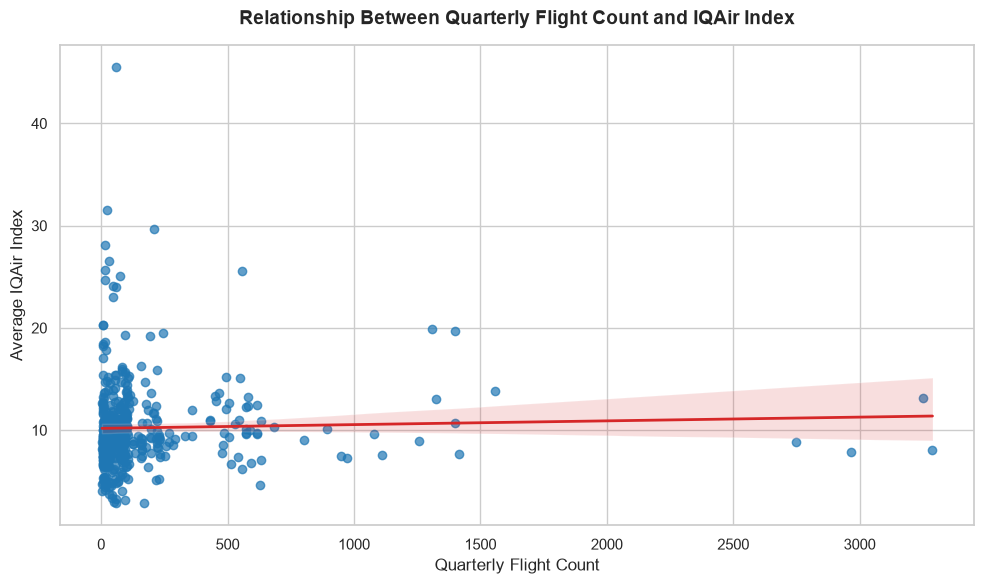

In [70]:
# Set the style and plot dimensions
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create a scatter plot with a linear regression trendline
sns.regplot(
            data=flights_iq_air_plot_df,
            x='quarter_flights_count',
            y='QuarterIQAir',
            scatter_kws={'alpha': 0.7, 'color': 'tab:blue'},
            line_kws={'color': 'tab:red', 'linewidth': 2}
            )

# Add titles and labels
plt.title('Relationship Between Quarterly Flight Count and IQAir Index', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Quarterly Flight Count', fontsize=12)
plt.ylabel('Average IQAir Index', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

*Answer to research question:*  
The most polluted cities are on the left side of the Quarterly flights counts, meaning the aviation is not the main factor of pollution in these cities.

#### **5.1.2:** Air quality vs. flight volume of the top 10 most polluted cities

If flights are the primary cause of severe air pollution, the most polluted cities will also those with the highest flight counts.

In [71]:
# select most polluted cities and calculate their average quaterly IQAir and flight counts
top_polluted = (
                flights_iq_air_plot_df.groupby('City')[['QuarterIQAir', 'quarter_flights_count']]
                .mean()
                .nlargest(10, 'QuarterIQAir')
                .reset_index()
                )

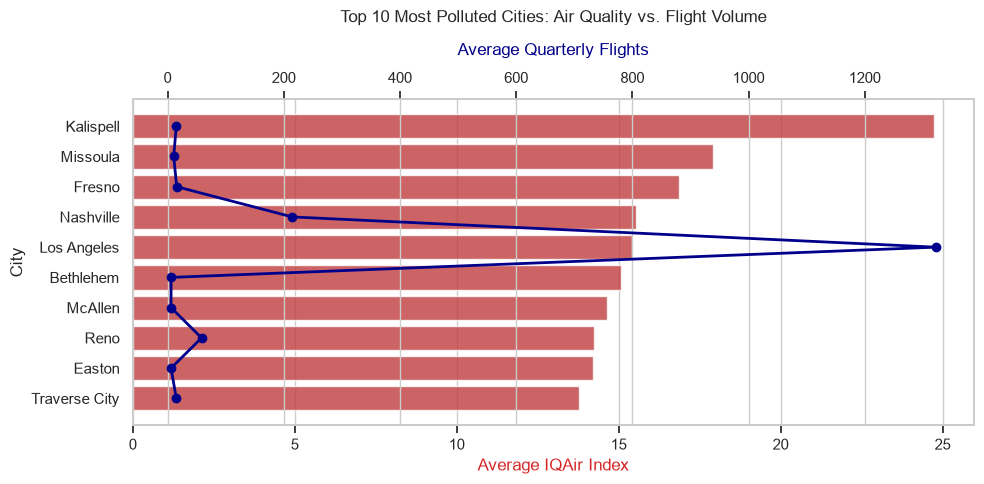

In [72]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot IQAir Index
sns.barplot(data=top_polluted, y='City', x='QuarterIQAir', color='tab:red', ax=ax1, alpha=0.8)
ax1.set_xlabel('Average IQAir Index', color='tab:red')
ax1.set_title('Top 10 Most Polluted Cities: Air Quality vs. Flight Volume', pad=15)

# Overlay Flight Count as markers
# create second axis shared with first plot
ax2 = ax1.twiny()
ax2.plot(top_polluted['quarter_flights_count'], top_polluted['City'], color='darkblue', marker='o', linewidth=2)
ax2.set_xlabel('Average Quarterly Flights', color='darkblue', labelpad=12)

plt.tight_layout()
plt.show()

*Answer to research question:*   
Once again we can see that Kalispell, the most polluted city in this dataset is not the one with most flights. Los Angeles has more and is less polluted.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:*   
Having more time,
- I would compare the airport id and the cities to make sure there is no mismatch and the information entered is of quality.
- I would have added a third dataset about the weather as it impacts pollution.
- I woud have investigated more in depth the data:  
      - Do we have enough data for each city to be representative?  
      - Is the flights dataset exhaustive?  
      - Is the quarter important? Does flights impact more the pollution in summer?